In [16]:
import os
import sys
import random
import math
from collections import Counter
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.utils import save_image, make_grid
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

REAL_DATASET_DIR = 'Dataset/color'
GEN_DATASET_DIR = 'Dataset/generated_segregated'
BATCH_SIZE = 32
GEN_EPOCHS = 50
VIT_EPOCHS = 30
NUM_GEN_PER_CLASS = 50

transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_dataset = ImageFolder(REAL_DATASET_DIR, transform=transform)
classes = full_dataset.classes
NUM_CLASSES = len(classes)
targets = np.array(full_dataset.targets)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dataset Loaded: {len(full_dataset)} images, {NUM_CLASSES} classes. Using device: {device}")

Dataset Loaded: 54305 images, 38 classes. Using device: cuda


In [17]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES):
        super(Generator, self).__init__()
        self.label_emb = nn.Embedding(n_classes, 100)
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(200, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, label_input], 1)
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES):
        super(Discriminator, self).__init__()
        self.n_classes = n_classes
        self.main = nn.Sequential(
            nn.Conv2d(3 + n_classes, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.final = nn.Sequential(
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        batch_size, _, height, width = img.shape
        one_hot = torch.zeros(batch_size, self.n_classes, device=img.device)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        one_hot = one_hot.unsqueeze(2).unsqueeze(3).expand(-1, -1, height, width)
        x = torch.cat([img, one_hot], 1)
        features = self.main(x)
        output = self.final(features)
        return output.view(-1, 1).squeeze(1)

netG = Generator(NUM_CLASSES).to(device)
netD = Discriminator(NUM_CLASSES).to(device)

netG.apply(weights_init)
netD.apply(weights_init)
print("Generator initialized successfully.")

Generator initialized successfully.


In [18]:
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True if torch.cuda.is_available() else False)
criterion_gan = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))

print(f"Starting Generator Training for {GEN_EPOCHS} Epochs on {device}...")
netG.train()
netD.train()

for epoch in range(GEN_EPOCHS):
    pbar = tqdm(full_loader, desc=f"Generator Epoch {epoch+1:02d}/{GEN_EPOCHS:02d}")
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        bsz = imgs.size(0)
        
        real = torch.full((bsz,), 0.9, device=device)
        fake = torch.zeros(bsz, device=device)
        
        netD.zero_grad()
        out_real = netD(imgs, labels)
        loss_real = criterion_gan(out_real, real)
        
        noise = torch.randn(bsz, 100, 1, 1, device=device)
        fake_imgs = netG(noise, labels)
        out_fake = netD(fake_imgs.detach(), labels)
        loss_fake = criterion_gan(out_fake, fake)
        
        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizerD.step()
        
        netG.zero_grad()
        out_fake_g = netD(fake_imgs, labels)
        g_loss = criterion_gan(out_fake_g, real)
        g_loss.backward()
        optimizerG.step()
        
        pbar.set_postfix({"D_loss": f"{d_loss.item():.4f}", "G_loss": f"{g_loss.item():.4f}"})

torch.save(netG.state_dict(), 'generator.pth')
print("Generator Training Completed! Saved checkpoint to 'generator.pth'.")

Starting Generator Training for 50 Epochs on cuda...


Generator Epoch 50/50: 100%|██████████| 1698/1698 [00:42<00:00, 40.22it/s, D_loss=0.3517, G_loss=4.4243]

Generator Training Completed! Saved checkpoint to 'generator.pth'.


In [19]:
def save_generated_images_segregated(netG, classes, output_dir=GEN_DATASET_DIR, num_per_class=NUM_GEN_PER_CLASS, device=device, batch_size=32):
    os.makedirs(output_dir, exist_ok=True)
    netG.eval()
    total_saved = 0
    
    print(f"Generating and saving {num_per_class} images per class into '{output_dir}'...")
    with torch.no_grad():
        for class_idx, class_name in enumerate(tqdm(classes, desc="Saving Segregated Classes")):
            class_folder = os.path.join(output_dir, class_name)
            os.makedirs(class_folder, exist_ok=True)
            
            images_generated = 0
            while images_generated < num_per_class:
                cur_batch = min(batch_size, num_per_class - images_generated)
                labels = torch.full((cur_batch,), class_idx, dtype=torch.long, device=device)
                noise = torch.randn(cur_batch, 100, 1, 1, device=device)
                fake_imgs = netG(noise, labels)
                
                for b in range(cur_batch):
                    img_idx = images_generated + b + 1
                    img_path = os.path.join(class_folder, f"{class_name}_gen_{img_idx:04d}.png")
                    save_image(fake_imgs[b], img_path, normalize=True, value_range=(-1, 1))
                    
                images_generated += cur_batch
                total_saved += cur_batch
                
    print(f"Done! Successfully saved {total_saved} images across {len(classes)} class subfolders.")

save_generated_images_segregated(netG, classes, output_dir=GEN_DATASET_DIR, num_per_class=NUM_GEN_PER_CLASS, device=device)

Generating and saving 50 images per class into 'Dataset/generated_segregated'...


Saving Segregated Classes: 100%|██████████| 38/38 [00:05<00:00,  7.00it/s]

Done! Successfully saved 1900 images across 38 class subfolders.


In [20]:
class Balanced5050Dataset(Dataset):
    def __init__(self, real_dir=REAL_DATASET_DIR, gen_dir=GEN_DATASET_DIR, n_real=50, n_gen=50, transform=None, seed=42):
        super().__init__()
        self.transform = transform
        self.samples = []
        
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)
            
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
        self.classes = sorted([d for d in os.listdir(real_dir) if os.path.isdir(os.path.join(real_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for class_idx, class_name in enumerate(self.classes):
            real_class_dir = os.path.join(real_dir, class_name)
            real_files = [os.path.join(real_class_dir, f) for f in os.listdir(real_class_dir) if f.lower().endswith(valid_exts)]
            sampled_real = random.sample(real_files, n_real) if len(real_files) >= n_real else random.choices(real_files, k=n_real)
            for p in sampled_real:
                self.samples.append((p, class_idx, 0))
                
            gen_class_dir = os.path.join(gen_dir, class_name)
            gen_files = [os.path.join(gen_class_dir, f) for f in os.listdir(gen_class_dir) if f.lower().endswith(valid_exts)]
            sampled_gen = random.sample(gen_files, n_gen) if len(gen_files) >= n_gen else random.choices(gen_files, k=n_gen)
            for p in sampled_gen:
                self.samples.append((p, class_idx, 1))
                
        random.shuffle(self.samples)
        self.targets = [s[1] for s in self.samples]
        self.sources = [s[2] for s in self.samples]
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        path, label, is_gen = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label, is_gen

balanced_dataset = Balanced5050Dataset(
    real_dir=REAL_DATASET_DIR,
    gen_dir=GEN_DATASET_DIR,
    n_real=NUM_GEN_PER_CLASS,
    n_gen=NUM_GEN_PER_CLASS,
    transform=transform,
    seed=42
)

real_count = sum(1 for s in balanced_dataset.sources if s == 0)
gen_count  = sum(1 for s in balanced_dataset.sources if s == 1)
print(f"Total Balanced Dataset Size: {len(balanced_dataset)} images")
print(f"  - Original Images : {real_count} ({NUM_GEN_PER_CLASS} per class x {NUM_CLASSES} classes)")
print(f"  - Generated Images: {gen_count} ({NUM_GEN_PER_CLASS} per class x {NUM_CLASSES} classes)")

Total Balanced Dataset Size: 3800 images
  - Original Images : 1900 (50 per class x 38 classes)
  - Generated Images: 1900 (50 per class x 38 classes)


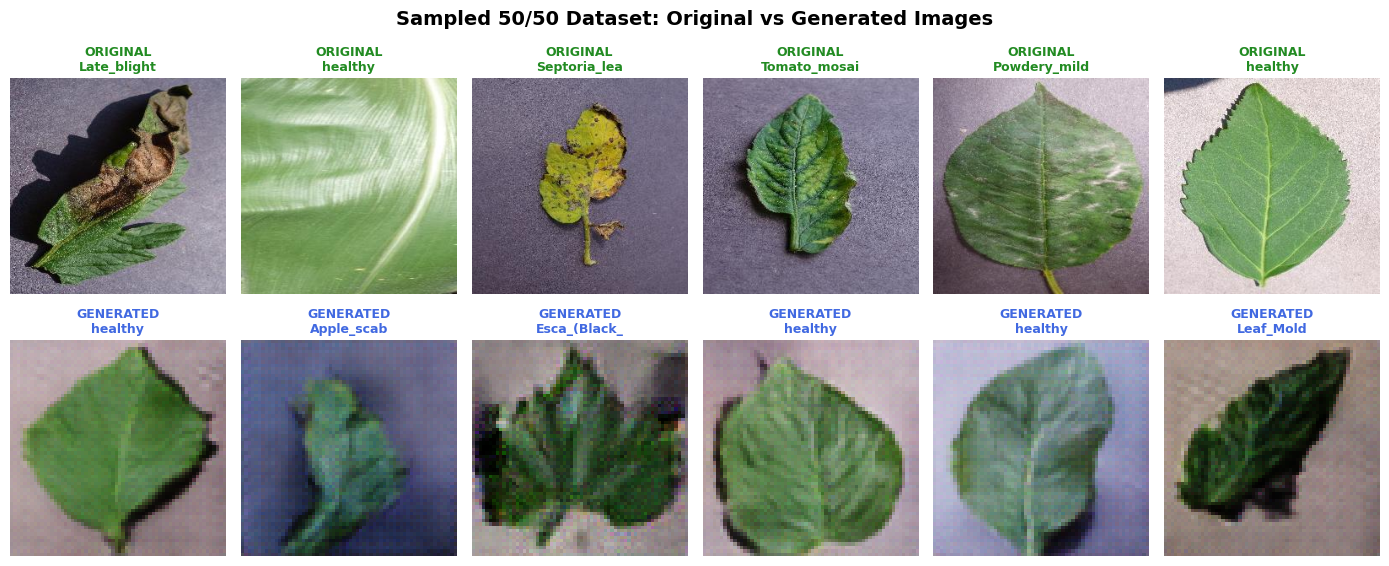

In [21]:
plt.figure(figsize=(14, 6))
real_samples = [s for s in balanced_dataset.samples if s[2] == 0][:6]
gen_samples  = [s for s in balanced_dataset.samples if s[2] == 1][:6]

for idx, (path, label, is_gen) in enumerate(real_samples + gen_samples):
    plt.subplot(2, 6, idx + 1)
    img = Image.open(path)
    plt.imshow(img)
    source_tag = "ORIGINAL" if is_gen == 0 else "GENERATED"
    tag_color = "forestgreen" if is_gen == 0 else "royalblue"
    short_cls = classes[label].split("___")[-1][:12]
    plt.title(f"{source_tag}\n{short_cls}", fontsize=9, color=tag_color, fontweight='bold')
    plt.axis('off')

plt.suptitle("Sampled 50/50 Dataset: Original vs Generated Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(3, 128, kernel_size=8, stride=8)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

class TransformerEncoderBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(128)
        self.attn = nn.MultiheadAttention(128, 4, dropout=0.1, batch_first=True)
        self.norm2 = nn.LayerNorm(128)

        self.mlp = nn.Sequential(
            nn.Linear(128, 512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.Dropout(0.1)
        )

    def forward(self, x):
        norm_x = self.norm1(x)
        attn_out, _ = self.attn(norm_x, norm_x, norm_x)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x))
        return x

class VisionTransformer(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.patch_embed = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 128))
        self.pos_embed = nn.Parameter(torch.zeros(1, 65, 128))
        self.pos_drop = nn.Dropout(p=0.1)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock()
            for _ in range(6)
        ])

        self.norm = nn.LayerNorm(128)
        self.head = nn.Linear(128, num_classes)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        cls_out = x[:, 0]
        logits = self.head(cls_out)
        return logits

vit_model = VisionTransformer(NUM_CLASSES).to(device)
print("Vision Transformer Initialized successfully.")
print(f"Trainable Parameters: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad):,}")

Vision Transformer Initialized successfully.
Trainable Parameters: 1,227,942


In [23]:
targets = np.array(balanced_dataset.targets)
train_idx, val_idx = train_test_split(
    np.arange(len(balanced_dataset)),
    test_size=0.20,
    random_state=42,
    stratify=targets
)

train_subset = Subset(balanced_dataset, train_idx)
val_subset   = Subset(balanced_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True if torch.cuda.is_available() else False)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True if torch.cuda.is_available() else False)

print(f"Training Set (80%)  : {len(train_subset)} images")
print(f"Validation Set (20%): {len(val_subset)} images")

Training Set (80%)  : 3040 images
Validation Set (20%): 760 images


In [24]:
criterion_vit = nn.CrossEntropyLoss()
optimizer_vit = optim.AdamW(vit_model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=VIT_EPOCHS)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print("Starting Vision Transformer Training...")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    vit_model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"ViT Epoch {epoch+1:02d}/{VIT_EPOCHS:02d}")
    
    for imgs, labels, _ in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer_vit.zero_grad()
        logits = vit_model(imgs)
        loss = criterion_vit(logits, labels)
        loss.backward()
        optimizer_vit.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({"Loss": f"{loss.item():.4f}", "Acc": f"{100.0 * correct / total:.2f}%"})
        
    scheduler_vit.step()
    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    
    vit_model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels, _ in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = vit_model(imgs)
            loss = criterion_vit(logits, labels)
            val_loss_sum += loss.item() * imgs.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            
    val_loss = val_loss_sum / val_total
    val_acc = 100.0 * val_correct / val_total
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(vit_model.state_dict(), 'vit_generator_best.pth')
        
    print(f"Epoch {epoch+1:02d}/{VIT_EPOCHS:02d} -> Train Loss: {train_loss:.4f} (Acc: {train_acc:.2f}%) | Val Loss: {val_loss:.4f} (Acc: {val_acc:.2f}%)")

Starting Vision Transformer Training...


ViT Epoch 01/30: 100%|██████████| 95/95 [00:31<00:00,  3.00it/s, Loss=2.4340, Acc=24.47%]


Epoch 01/30 -> Train Loss: 3.0318 (Acc: 24.47%) | Val Loss: 2.6176 (Acc: 38.16%)


ViT Epoch 02/30: 100%|██████████| 95/95 [00:10<00:00,  9.49it/s, Loss=1.9630, Acc=47.50%]


Epoch 02/30 -> Train Loss: 2.2487 (Acc: 47.50%) | Val Loss: 1.9554 (Acc: 53.68%)


...

Epoch 28/30 -> Train Loss: 0.0400 (Acc: 99.84%) | Val Loss: 0.4957 (Acc: 84.87%)


ViT Epoch 29/30: 100%|██████████| 95/95 [00:05<00:00, 16.72it/s, Loss=0.0171, Acc=99.80%] 


Epoch 29/30 -> Train Loss: 0.0369 (Acc: 99.80%) | Val Loss: 0.4913 (Acc: 84.87%)


ViT Epoch 30/30: 100%|██████████| 95/95 [00:05<00:00, 16.65it/s, Loss=0.0347, Acc=99.90%]


Epoch 30/30 -> Train Loss: 0.0376 (Acc: 99.90%) | Val Loss: 0.4913 (Acc: 85.00%)


          FINAL BALANCED ViT RESULTS
Overall Validation Accuracy : 85.00%
  - Original Images Accuracy: 77.51%
  - Generated Images Accuracy: 92.41%
Weighted Precision          : 0.8550
Weighted Recall             : 0.8500
Weighted F1-Score           : 0.8487


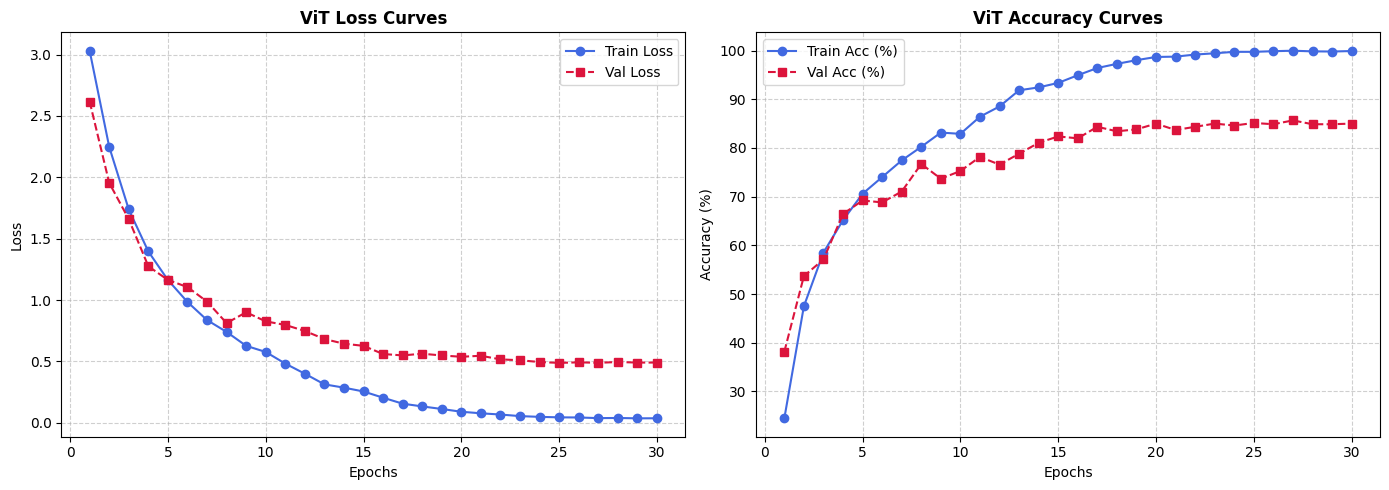

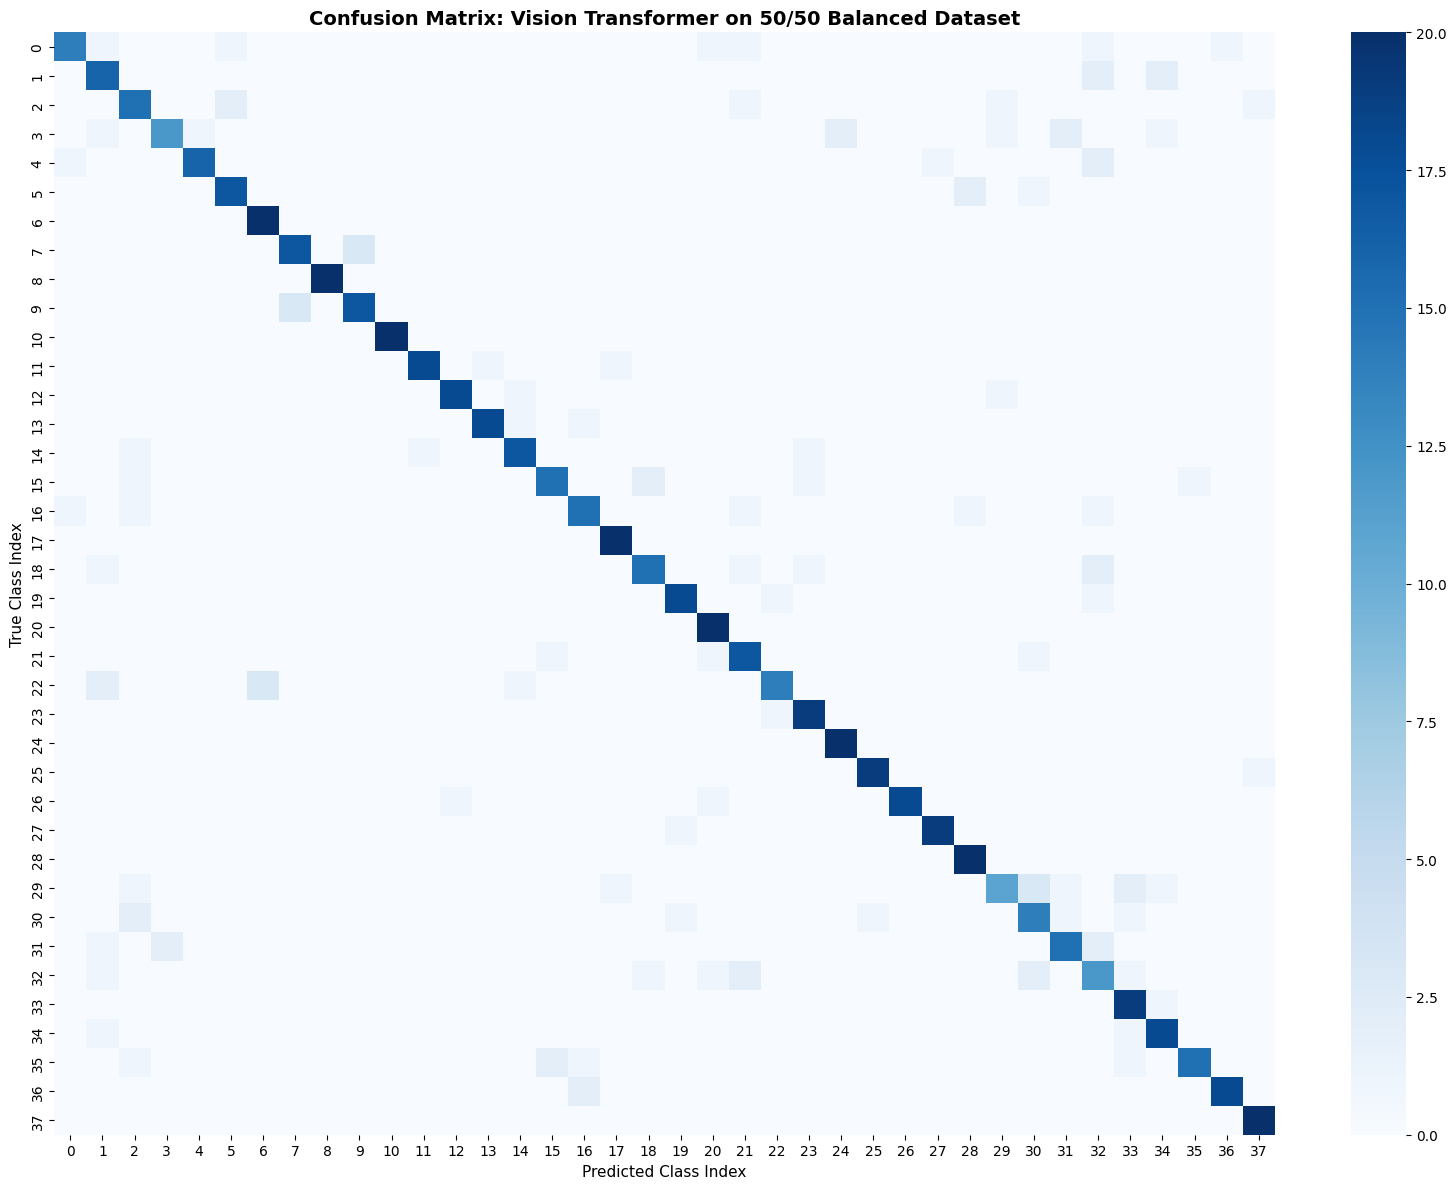

In [25]:
vit_model.eval()
all_preds, all_targets, all_sources = [], [], []

with torch.no_grad():
    for imgs, labels, is_gen in val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = vit_model(imgs)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(labels.cpu().numpy())
        all_sources.extend(is_gen.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)
all_sources = np.array(all_sources)

acc  = accuracy_score(all_targets, all_preds)
prec = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
rec  = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
f1   = f1_score(all_targets, all_preds, average='weighted', zero_division=0)

real_mask = (all_sources == 0)
gen_mask  = (all_sources == 1)
acc_real = accuracy_score(all_targets[real_mask], all_preds[real_mask]) if np.any(real_mask) else 0.0
acc_gen  = accuracy_score(all_targets[gen_mask], all_preds[gen_mask]) if np.any(gen_mask) else 0.0

print("=" * 65)
print("          FINAL BALANCED ViT RESULTS")
print("=" * 65)
print(f"Overall Validation Accuracy : {acc * 100:.2f}%")
print(f"  - Original Images Accuracy: {acc_real * 100:.2f}%")
print(f"  - Generated Images Accuracy: {acc_gen * 100:.2f}%")
print(f"Weighted Precision          : {prec:.4f}")
print(f"Weighted Recall             : {rec:.4f}")
print(f"Weighted F1-Score           : {f1:.4f}")
print("=" * 65)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(history['train_loss']) + 1), history['train_loss'], 'o-', label='Train Loss', color='royalblue')
axes[0].plot(range(1, len(history['val_loss']) + 1), history['val_loss'], 's--', label='Val Loss', color='crimson')
axes[0].set_title("ViT Loss Curves", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(range(1, len(history['train_acc']) + 1), history['train_acc'], 'o-', label='Train Acc (%)', color='royalblue')
axes[1].plot(range(1, len(history['val_acc']) + 1), history['val_acc'], 's--', label='Val Acc (%)', color='crimson')
axes[1].set_title("ViT Accuracy Curves", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title("Confusion Matrix: Vision Transformer on 50/50 Balanced Dataset", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Class Index", fontsize=11)
plt.ylabel("True Class Index", fontsize=11)
plt.tight_layout()
plt.show()